# Processed Data Quality Checks

**Purpose:** Systematic validation of `data/processed/RTT.xlsx` to catch data entry errors, merge failures, preprocessing bugs, and logical inconsistencies before any modelling work.

**Dataset:** `RTT.xlsx` — 14,359 rows × 45 columns · 28 players · 597 days (2024-07-01 → 2026-02-17)

---

## Sections
1. [Setup & Overview](#1.-Setup-&-Overview)
2. [Row-Level Completeness](#2.-Row-Level-Completeness)
3. [Match Day & Selection Consistency](#3.-Match-Day-&-Selection-Consistency)
4. [Training Intensity Consistency](#4.-Training-Intensity-Consistency)
5. [Temporal Variable Consistency](#5.-Temporal-Variable-Consistency)
6. [ACWR Flag Consistency](#6.-ACWR-Flag-Consistency)
7. [Status & Status Decrease Logic](#7.-Status-&-Status-Decrease-Logic)
8. [Wellness Z-Score Validation](#8.-Wellness-Z-Score-Validation)
9. [Cross-Dataset Merge Coverage](#9.-Cross-Dataset-Merge-Coverage)
10. [Free Day Consistency](#10.-Free-Day-Consistency)
11. [Summary Dashboard](#11.-Summary-Dashboard)

## 1. Setup & Overview

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from pathlib import Path

# ── paths ─────────────────────────────────────────────────────────────────────
ROOT = Path('..').resolve()
DATA_PATH = ROOT / 'data' / 'processed' / 'RTT.xlsx'

# ── colour palette ────────────────────────────────────────────────────────────
C_NAVY   = '#1a2744'
C_BLUE   = '#2c5f9e'
C_AMBER  = '#e07b39'
C_TEAL   = '#2a9d8f'
C_RED    = '#c0392b'
C_GREEN  = '#27ae60'
C_GRAY   = '#95a5a6'
C_LTBLUE = '#e8f0fb'

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

# ── tracking dict for summary dashboard ───────────────────────────────────────
CHECKS = {}  # {check_name: {'status': 'PASS'/'WARN'/'FAIL', 'n': int, 'note': str}}

def log(name, status, n=0, note=''):
    """Record a check result."""
    CHECKS[name] = {'status': status, 'n': n, 'note': note}
    icon = {'PASS': '✅', 'WARN': '⚠️ ', 'FAIL': '❌'}[status]
    msg = f"{icon}  {name}"
    if n:
        msg += f" — {n:,} affected rows"
    if note:
        msg += f"  [{note}]"
    print(msg)

print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── load data ─────────────────────────────────────────────────────────────────
df = pd.read_excel(DATA_PATH, parse_dates=['Date'])
df['Date'] = pd.to_datetime(df['Date']).dt.normalize()   # strip time component

print(f"Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range     : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Unique dates   : {df['Date'].nunique():,}")
print(f"Unique players : {df['Player ID'].nunique()} (IDs: {sorted(df['Player ID'].unique())})")
print()

# convenience
ALL_DATES     = pd.date_range(df['Date'].min(), df['Date'].max(), freq='D')
N_DAYS        = len(ALL_DATES)
ALL_PLAYER_IDS = sorted(df['Player ID'].unique())

# ACWR columns
ACWR_COLS = [
    'Total Distance (ACWR) Yesterday',
    'High Speed Distance (ACWR) Yesterday',
    'High Decelerations (ACWR) Yesterday',
    'Sprints (ACWR) Yesterday',
]

# GPS % columns used for Training Intensity
GPS_PCT_COLS = [
    'Total Distance % Yesterday',
    'High Speed Distance % Yesterday',
    'High Decelerations % Yesterday',
    'Sprints % Yesterday',
]

# Wellness z-score columns
WELLNESS_Z_COLS = [
    'Fatigue (z)', 'Readiness (z)', 'Soreness (z)',
    'Sleep Quality (z)', 'Stress (z)', 'Mood (z)',
]

print(f"Total calendar days in span: {N_DAYS}")

Shape          : 5,234 rows × 45 columns
Date range     : 2025-07-27 → 2026-02-17
Unique dates   : 206
Unique players : 28 (IDs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28)])

Total calendar days in span: 206


In [3]:
# ── column overview ───────────────────────────────────────────────────────────
col_info = pd.DataFrame({
    'dtype'      : df.dtypes,
    'non_null'   : df.notna().sum(),
    'null'       : df.isna().sum(),
    'null_%'     : (df.isna().mean() * 100).round(1),
    'nunique'    : df.nunique(),
})

print(col_info.to_string())

                                                 dtype  non_null  null  null_%  nunique
Date                                    datetime64[us]      5234     0     0.0      206
Playerkey                                          str      5234     0     0.0       28
Player ID                                        int64      5234     0     0.0       28
Position                                           str      5234     0     0.0        7
Medical Availability Last 14 Days                int64      5234     0     0.0       15
Club Attendance Last 14 Days                   float64      4976   258     4.9       49
Total Distance (ACWR) Yesterday                float64      5078   156     3.0      237
High Speed Distance (ACWR) Yesterday           float64      5062   172     3.3      255
High Decelerations (ACWR) Yesterday            float64      5018   216     4.1      256
Sprints (ACWR) Yesterday                       float64      5051   183     3.5      256
Any ACWR Danger                 

## 2. Row-Level Completeness

**Rules:**
- Every player who is "active" (in the squad) on a given date must have exactly one row for that date.
- The squad composition may change over time (transfers, loans). We detect the actual expected player set from the data itself.
- No player should appear **twice** on the same date.
- We expect three distinct squad periods based on the data structure.

In [4]:
# ── 2.1  Player count per date ────────────────────────────────────────────────
players_per_date = df.groupby('Date')['Player ID'].count().rename('n_players')

print("Distribution of player counts per date:")
print(players_per_date.value_counts().sort_index().rename('n_dates').to_frame())
print()

# detect squad transition dates
transitions = players_per_date[players_per_date.diff() != 0]
print("Squad size transitions:")
for d, n in transitions.items():
    print(f"  {d.date()} → {n} players")

Distribution of player counts per date:
           n_dates
n_players         
23              82
27             124

Squad size transitions:
  2025-07-27 → 27 players
  2025-11-28 → 23 players


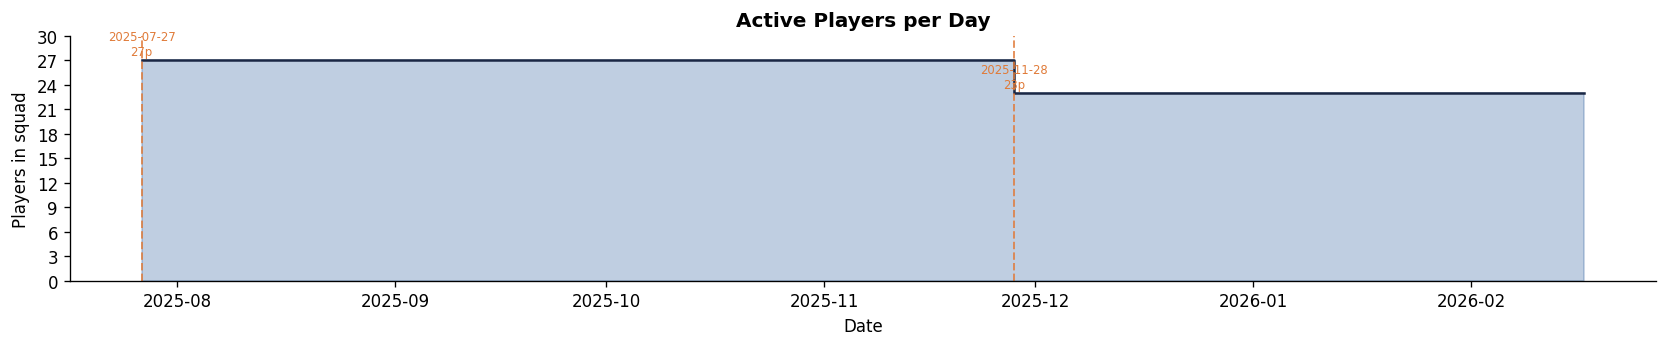

In [5]:
# ── visualise player count over time ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3))

ax.fill_between(players_per_date.index, players_per_date.values,
                step='post', alpha=0.3, color=C_BLUE)
ax.step(players_per_date.index, players_per_date.values,
        where='post', color=C_NAVY, linewidth=1.5)

# annotate transitions
for d, n in transitions.items():
    ax.axvline(d, color=C_AMBER, linewidth=1.2, linestyle='--', alpha=0.8)
    ax.text(d, n + 0.3, f'{d.date()}\n{n}p', fontsize=7,
            ha='center', va='bottom', color=C_AMBER)

ax.set_xlabel('Date')
ax.set_ylabel('Players in squad')
ax.set_title('Active Players per Day', fontweight='bold')
ax.set_ylim(0, players_per_date.max() + 3)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
fig.tight_layout()
plt.show()

In [6]:
# ── 2.2  Detect squad periods ─────────────────────────────────────────────────
# For each date, which players are present?
presence = df.pivot_table(index='Date', columns='Player ID', values='Playerkey',
                          aggfunc='count').notna()

# per-player active date ranges
player_ranges = {}
for pid in ALL_PLAYER_IDS:
    active_dates = presence.index[presence[pid]]
    player_ranges[pid] = {
        'first'  : active_dates.min(),
        'last'   : active_dates.max(),
        'n_dates': len(active_dates),
    }

pr_df = pd.DataFrame(player_ranges).T
pr_df.index.name = 'Player ID'
# Convert to datetime (DataFrame.T creates object dtype columns)
pr_df['first'] = pd.to_datetime(pr_df['first'])
pr_df['last']  = pd.to_datetime(pr_df['last'])
pr_df['span_days'] = (pr_df['last'] - pr_df['first']).dt.days + 1
pr_df['missing']   = pr_df['span_days'].astype(int) - pr_df['n_dates'].astype(int)

print(pr_df.to_string())

               first       last n_dates  span_days  missing
Player ID                                                  
1         2025-07-27 2026-02-17     206        206        0
2         2025-11-28 2026-02-17      82         82        0
3         2025-07-27 2026-02-17     206        206        0
4         2025-07-27 2026-02-17     206        206        0
5         2025-07-27 2026-02-17     206        206        0
6         2025-07-27 2026-02-17     206        206        0
7         2025-07-27 2026-02-17     206        206        0
8         2025-07-27 2025-11-27     124        124        0
9         2025-07-27 2026-02-17     206        206        0
10        2025-07-27 2026-02-17     206        206        0
11        2025-07-27 2025-11-27     124        124        0
12        2025-07-27 2026-02-17     206        206        0
13        2025-07-27 2025-11-27     124        124        0
14        2025-07-27 2026-02-17     206        206        0
15        2025-07-27 2026-02-17     206 

In [7]:
# ── 2.3  Missing dates per player ─────────────────────────────────────────────
issues_missing = []

for pid in ALL_PLAYER_IDS:
    r      = player_ranges[pid]
    span   = pd.date_range(r['first'], r['last'], freq='D')
    actual = set(presence.index[presence[pid]])
    missing_dates = sorted(set(span) - actual)

    if missing_dates:
        issues_missing.append({
            'player_id'    : pid,
            'n_missing'    : len(missing_dates),
            'first_missing': pd.Timestamp(missing_dates[0]).date(),
            'last_missing' : pd.Timestamp(missing_dates[-1]).date(),
        })
        print(f"Player {pid:2d}: {len(missing_dates)} missing date(s) "
              f"from {missing_dates[0].date()} to {missing_dates[-1].date()}")

if not issues_missing:
    print("No missing dates within any player's active span.")

status = 'PASS' if not issues_missing else ('WARN' if len(issues_missing) <= 3 else 'FAIL')
total_missing = sum(i['n_missing'] for i in issues_missing)
log('Missing player-date rows within active spans',
    status, total_missing,
    note=f'{len(issues_missing)} player(s) affected')

No missing dates within any player's active span.
✅  Missing player-date rows within active spans  [0 player(s) affected]


In [8]:
# ── 2.4  Duplicate player-date rows ───────────────────────────────────────────
dups = df[df.duplicated(['Date', 'Player ID'], keep=False)]

if dups.empty:
    print('No duplicate (Date, Player ID) combinations.')
else:
    print(f'{len(dups):,} rows are part of duplicate (Date, Player ID) groups:')
    print(dups[['Date','Player ID','Status']].to_string())

log('Duplicate player-date rows', 'PASS' if dups.empty else 'FAIL', len(dups))

No duplicate (Date, Player ID) combinations.
✅  Duplicate player-date rows


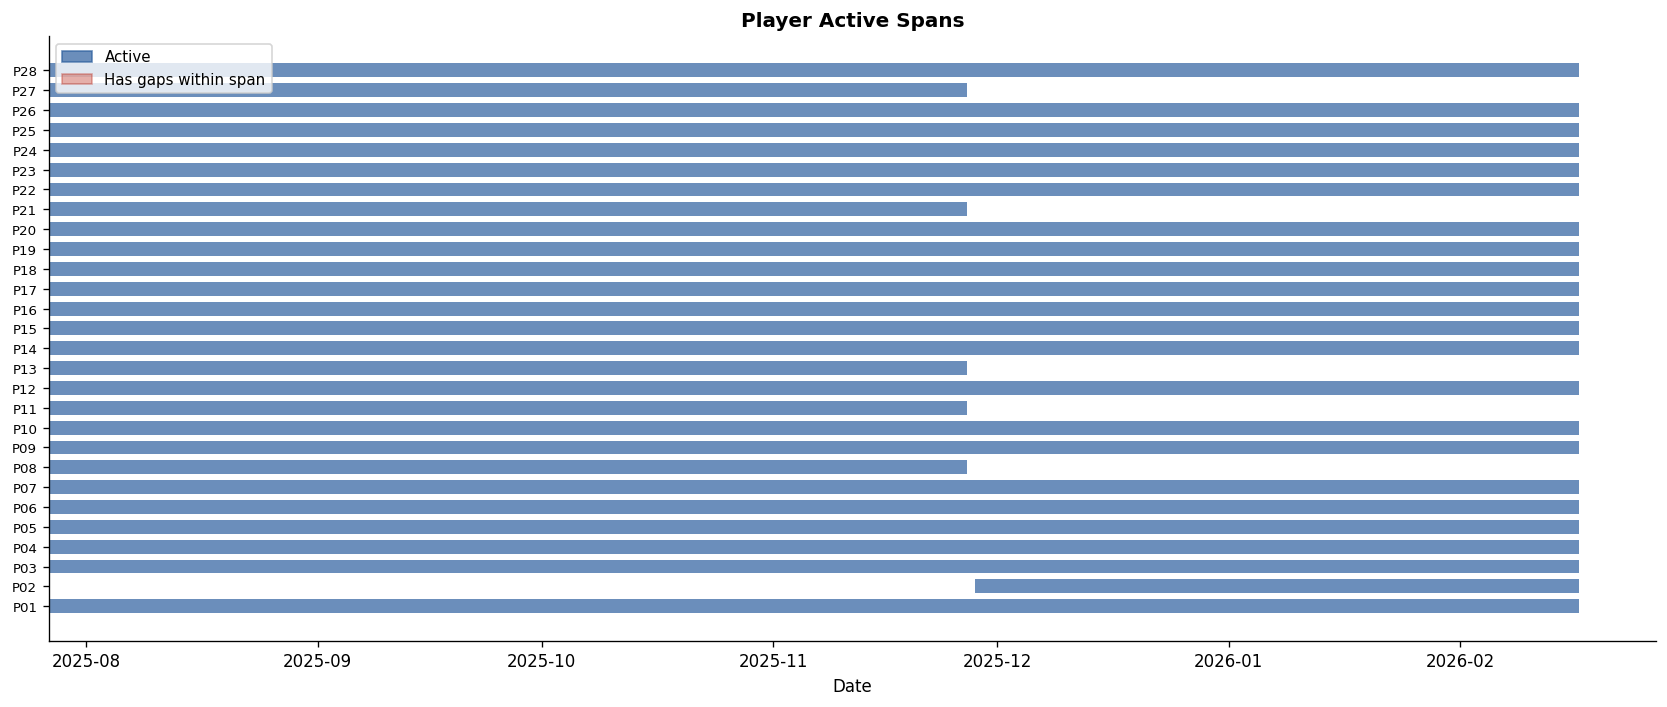

In [9]:
# ── 2.5  Visualise per-player timeline ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

for i, pid in enumerate(ALL_PLAYER_IDS):
    r = player_ranges[pid]
    ax.barh(i, (r['last'] - r['first']).days, left=r['first'],
            height=0.7, color=C_BLUE, alpha=0.7)
    if pr_df.loc[pid, 'missing'] > 0:
        ax.barh(i, (r['last'] - r['first']).days, left=r['first'],
                height=0.7, color=C_RED, alpha=0.4, label='has gaps' if i == 0 else '')

ax.set_yticks(range(len(ALL_PLAYER_IDS)))
ax.set_yticklabels([f'P{pid:02d}' for pid in ALL_PLAYER_IDS], fontsize=8)
ax.set_xlabel('Date')
ax.set_title('Player Active Spans', fontweight='bold')

# legend
blue_patch = mpatches.Patch(color=C_BLUE, alpha=0.7, label='Active')
red_patch  = mpatches.Patch(color=C_RED,  alpha=0.4, label='Has gaps within span')
ax.legend(handles=[blue_patch, red_patch], loc='upper left', fontsize=9)

fig.tight_layout()
plt.show()

## 3. Match Day & Selection Consistency

**Rules:**
- `Match Day = 1` on team-level match dates. Every player (regardless of selection) should have `Match Day = 1` on those dates.
- `Selected = 1` players on a match day must have `Activity Type Today == 'Game'`.
- `Selected = 0` players must **not** have `Activity Type Today == 'Game'`.
- Day after a match, selected players should have match performance data (`Match HID Per BIP Yesterday` filled).
- `Days Until Match = 0` on (and only on) match days.

In [10]:
# ── 3.1  Match day consistency across players ──────────────────────────────────
match_dates = set(df.loc[df['Match Day'] == 1, 'Date'].unique())
print(f"Unique match dates (Match Day==1): {len(match_dates)}")

# Every player present on a match date should have Match Day == 1
player_on_match_date = df[df['Date'].isin(match_dates)]
wrong_matchday = player_on_match_date[player_on_match_date['Match Day'] != 1]

if wrong_matchday.empty:
    print('All players on match dates have Match Day == 1.')
else:
    print(f'{len(wrong_matchday):,} player-rows on a match date but Match Day != 1:')
    print(wrong_matchday[['Date','Player ID','Match Day','Activity Type Today']].to_string())

log('Match Day flag consistent across all players on match dates',
    'PASS' if wrong_matchday.empty else 'FAIL', len(wrong_matchday))

Unique match dates (Match Day==1): 29
All players on match dates have Match Day == 1.
✅  Match Day flag consistent across all players on match dates


In [11]:
# ── 3.2  Selected players have Activity Type Today == 'Game' ──────────────────
selected_rows = df[df['Selected'] == 1]
not_game      = selected_rows[selected_rows['Activity Type Today'] != 'Game']

print(f"Selected==1 rows        : {len(selected_rows):,}")
print(f"Of which Activity != 'Game': {len(not_game):,}")
if not not_game.empty:
    print(not_game[['Date','Player ID','Activity Type Today','Match Day']].head(20).to_string())

log('Selected players have Activity Type Today == Game',
    'PASS' if not_game.empty else 'FAIL', len(not_game))

Selected==1 rows        : 499
Of which Activity != 'Game': 0
✅  Selected players have Activity Type Today == Game


In [12]:
# ── 3.3  Non-selected players on match days do NOT have Activity == 'Game' ────
on_matchday_not_selected = df[(df['Match Day'] == 1) & (df['Selected'] == 0)]
falsely_game = on_matchday_not_selected[
    on_matchday_not_selected['Activity Type Today'] == 'Game'
]

print(f"On match day, Selected==0 rows : {len(on_matchday_not_selected):,}")
print(f"Of which Activity == 'Game'    : {len(falsely_game):,}")
if not falsely_game.empty:
    print(falsely_game[['Date','Player ID','Activity Type Today','Selected']].to_string())

log('Non-selected players on match days are NOT marked as Game',
    'PASS' if falsely_game.empty else 'FAIL', len(falsely_game))

On match day, Selected==0 rows : 193
Of which Activity == 'Game'    : 0
✅  Non-selected players on match days are NOT marked as Game


In [13]:
# ── 3.4  Selected players: match performance filled day after ─────────────────
# Selected players played a game → next day row should have Match* Yesterday filled.
# We look at rows where Activity Type Today == 'Game' (i.e., player was selected and played)
# and check whether the NEXT day's Match HID Per BIP Yesterday is non-NaN.

game_rows = df[df['Activity Type Today'] == 'Game'][['Date', 'Player ID']].copy()
game_rows['next_date'] = game_rows['Date'] + pd.Timedelta(days=1)

# merge to get next-day row
next_day = df[['Date','Player ID','Match HID Per BIP Yesterday']].rename(
    columns={'Date': 'next_date', 'Match HID Per BIP Yesterday': 'match_perf_next'}
)
merged = game_rows.merge(next_day, on=['next_date','Player ID'], how='left')

missing_perf = merged[merged['match_perf_next'].isna()]
fill_rate    = (merged['match_perf_next'].notna().sum() / len(merged) * 100)

print(f"Game rows (Activity Type Today == 'Game') : {len(game_rows):,}")
print(f"Next-day match performance filled         : {merged['match_perf_next'].notna().sum():,} "
      f"({fill_rate:.1f}%)")
print(f"Missing next-day match performance        : {len(missing_perf):,}")

if len(missing_perf) > 0:
    print("\nRows where match performance is missing the day after a game:")
    print(missing_perf.head(20).to_string())

# WARN if fill rate < 70%, FAIL if < 50%
status = 'PASS' if fill_rate >= 70 else ('WARN' if fill_rate >= 50 else 'FAIL')
log('Match performance filled day after game',
    status, len(missing_perf),
    note=f'{fill_rate:.1f}% fill rate')

Game rows (Activity Type Today == 'Game') : 499
Next-day match performance filled         : 348 (69.7%)
Missing next-day match performance        : 151

Rows where match performance is missing the day after a game:
          Date  Player ID  next_date  match_perf_next
11  2025-07-27          9 2025-07-28              NaN
13  2025-07-27         22 2025-07-28              NaN
16  2025-07-27         10 2025-07-28              NaN
27  2025-08-03          9 2025-08-04              NaN
30  2025-08-03         22 2025-08-04              NaN
36  2025-08-10          6 2025-08-11              NaN
46  2025-08-10         26 2025-08-11              NaN
49  2025-08-10         19 2025-08-11              NaN
55  2025-08-15         28 2025-08-16              NaN
64  2025-08-15         26 2025-08-16              NaN
67  2025-08-15         19 2025-08-16              NaN
70  2025-08-24         17 2025-08-25              NaN
74  2025-08-24         28 2025-08-25              NaN
81  2025-08-24         22 202

In [14]:
# ── 3.5  Selections per match: sanity range ────────────────────────────────────
selections_per_match = (
    df[df['Match Day'] == 1]
    .groupby('Date')['Selected']
    .apply(lambda x: (x == 1).sum())
    .rename('n_selected')
)

print("Selected players per match (distribution):")
print(selections_per_match.describe().round(1))
print()

# Flag matches with suspiciously few or many selections
flag_low  = selections_per_match[selections_per_match < 11]
flag_high = selections_per_match[selections_per_match > 18]

if not flag_low.empty:
    print("Matches with fewer than 11 selections (suspicious):")
    print(flag_low.to_string())

if not flag_high.empty:
    print("Matches with more than 18 selections (suspicious — large squad?):")
    print(flag_high.to_string())

n_issues = len(flag_low) + len(flag_high)
log('Selections per match in plausible range [11, 18]',
    'PASS' if n_issues == 0 else 'WARN', n_issues,
    note='low: %d, high: %d' % (len(flag_low), len(flag_high)))

Selected players per match (distribution):
count    29.0
mean     17.2
std       1.8
min      11.0
25%      16.0
50%      18.0
75%      18.0
max      19.0
Name: n_selected, dtype: float64

Matches with more than 18 selections (suspicious — large squad?):
Date
2025-08-24    19
2025-08-31    19
2025-09-20    19
2025-10-05    19
2025-10-10    19
2026-01-18    19
⚠️   Selections per match in plausible range [11, 18] — 6 affected rows  [low: 0, high: 6]


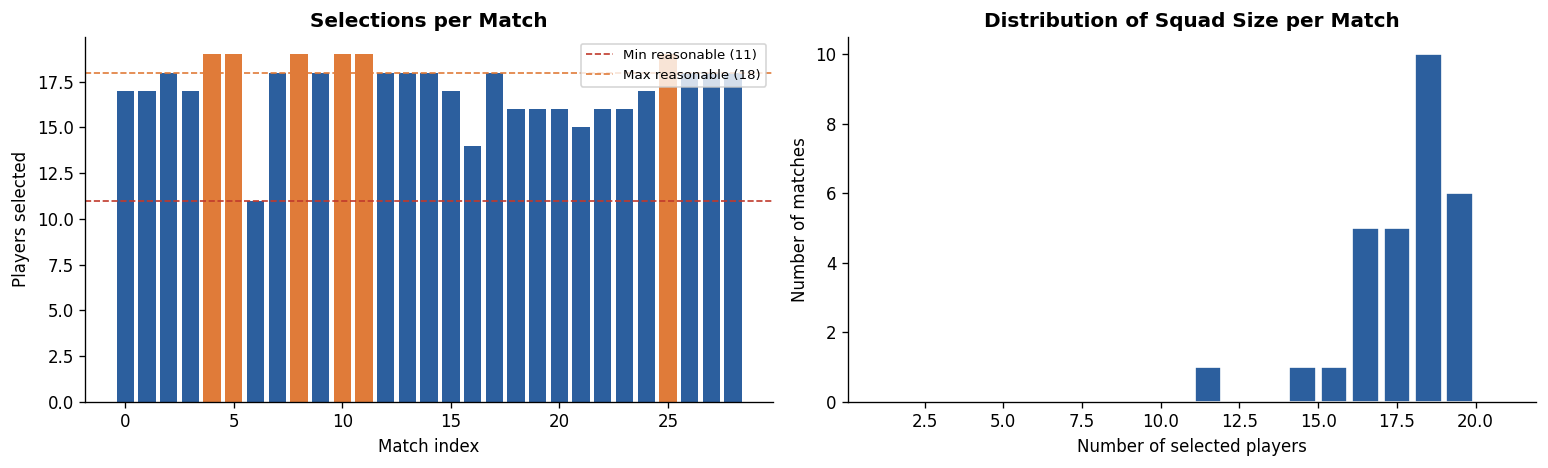

In [15]:
# ── visualise selections per match ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# time series
ax = axes[0]
colors = [C_RED if v < 11 else (C_AMBER if v > 18 else C_BLUE)
          for v in selections_per_match.values]
ax.bar(range(len(selections_per_match)), selections_per_match.values, color=colors, width=0.8)
ax.axhline(11, color=C_RED,   linestyle='--', linewidth=1, label='Min reasonable (11)')
ax.axhline(18, color=C_AMBER, linestyle='--', linewidth=1, label='Max reasonable (18)')
ax.set_xlabel('Match index')
ax.set_ylabel('Players selected')
ax.set_title('Selections per Match', fontweight='bold')
ax.legend(fontsize=8)

# histogram
ax = axes[1]
ax.hist(selections_per_match.values, bins=range(1, 22),
        color=C_BLUE, edgecolor='white', rwidth=0.85)
ax.set_xlabel('Number of selected players')
ax.set_ylabel('Number of matches')
ax.set_title('Distribution of Squad Size per Match', fontweight='bold')

fig.tight_layout()
plt.show()

## 4. Training Intensity Consistency

**Rules:**
- `Training Intensity Yesterday` must be in **[0, 1)** — `tanh(mean / 100)` is bounded below 1.
- When `Activity Type Yesterday == 'Free'`, GPS% columns should all be 0 and TI should be 0.
- When all GPS% cols are NaN, TI should **also** be NaN (or 0 for genuinely free days).
- TI and GPS% should be **coherent**: positive GPS% → positive TI; all-zero GPS% → TI ≈ 0.
- Match day selected players: their next day's TI (= this row's TI Yesterday) should reflect a game-level intensity.

In [16]:
# ── 4.1  TI range ─────────────────────────────────────────────────────────────
ti = df['Training Intensity Yesterday']

print(f"TI range     : [{ti.min():.6f}, {ti.max():.6f}]")
print(f"TI < 0       : {(ti < 0).sum():,}")
print(f"TI >= 1      : {(ti >= 1).sum():,}")
print(f"TI NaN       : {ti.isna().sum():,}")
print(f"TI == 0      : {(ti == 0).sum():,}")
print(f"TI in (0, 1) : {((ti > 0) & (ti < 1)).sum():,}")

bad_ti = df[(ti < 0) | (ti >= 1)].dropna(subset=['Training Intensity Yesterday'])
if not bad_ti.empty:
    print("\nOut-of-range TI rows:")
    print(bad_ti[['Date','Player ID','Training Intensity Yesterday'] + GPS_PCT_COLS].to_string())

log('Training Intensity in [0, 1)',
    'PASS' if bad_ti.empty else 'FAIL', len(bad_ti))

TI range     : [0.000000, 0.997915]
TI < 0       : 0
TI >= 1      : 0
TI NaN       : 1,997
TI == 0      : 38
TI in (0, 1) : 3,199
✅  Training Intensity in [0, 1)


In [17]:
# ── 4.2  Free days: GPS% == 0 and TI == 0 ─────────────────────────────────────
free_day_rows = df[df['Activity Type Yesterday'] == 'Free']
print(f"Free day rows (Activity Type Yesterday == 'Free'): {len(free_day_rows):,}")

# GPS% != 0 on free days
free_nonzero_gps = free_day_rows[
    (free_day_rows[GPS_PCT_COLS].fillna(0) != 0).any(axis=1)
]
print(f"Free days with non-zero GPS% : {len(free_nonzero_gps):,}")

# TI != 0 on free days
free_nonzero_ti = free_day_rows[
    free_day_rows['Training Intensity Yesterday'].fillna(0) != 0
]
print(f"Free days with TI != 0       : {len(free_nonzero_ti):,}")

if not free_nonzero_gps.empty:
    print("\nFree days with non-zero GPS%:")
    print(free_nonzero_gps[['Date','Player ID'] + GPS_PCT_COLS + ['Training Intensity Yesterday']].head(10).to_string())

n_issues = len(free_nonzero_gps) + len(free_nonzero_ti)
log('Free days have GPS% == 0 and TI == 0',
    'PASS' if n_issues == 0 else 'FAIL', n_issues)

Free day rows (Activity Type Yesterday == 'Free'): 1
Free days with non-zero GPS% : 0
Free days with TI != 0       : 0
✅  Free days have GPS% == 0 and TI == 0


In [18]:
# ── 4.3  GPS% / TI coherence ─────────────────────────────────────────────────
# Expected TI computed from GPS% columns (same formula as preprocessing)
gps_vals = df[GPS_PCT_COLS].copy()
gps_mean = gps_vals.mean(axis=1)  # NaN if all GPS% are NaN
ti_expected = np.tanh(gps_mean / 100)

ti_actual = df['Training Intensity Yesterday']

# compare only where both expected and actual are non-NaN
both_valid = ti_actual.notna() & ti_expected.notna()
ti_diff    = (ti_actual - ti_expected).abs()

# allow small floating point tolerance
TOLERANCE = 1e-4
incoherent = df[both_valid & (ti_diff > TOLERANCE)].copy()
incoherent['ti_actual']   = ti_actual[incoherent.index]
incoherent['ti_expected'] = ti_expected[incoherent.index]
incoherent['ti_diff']     = ti_diff[incoherent.index]

print(f"Rows where both TI_actual and TI_expected are non-NaN: {both_valid.sum():,}")
print(f"Incoherent (|actual - expected| > {TOLERANCE})         : {len(incoherent):,}")

if not incoherent.empty:
    print("\nTop mismatches:")
    cols = ['Date','Player ID','Activity Type Yesterday'] + GPS_PCT_COLS + ['ti_actual','ti_expected','ti_diff']
    print(incoherent[cols].sort_values('ti_diff', ascending=False).head(20).to_string())

log('Training Intensity coherent with GPS% values',
    'PASS' if incoherent.empty else 'WARN', len(incoherent),
    note='possible free days with partial GPS data')

Rows where both TI_actual and TI_expected are non-NaN: 3,237
Incoherent (|actual - expected| > 0.0001)         : 25

Top mismatches:
           Date  Player ID      Activity Type Yesterday  Total Distance % Yesterday  High Speed Distance % Yesterday  High Decelerations % Yesterday  Sprints % Yesterday  ti_actual  ti_expected   ti_diff
1177 2025-09-08         13                          NaN                        70.0                            250.0                             NaN                  NaN   0.988807     0.921669  0.067138
1172 2025-09-08         25                          NaN                        66.0                            250.0                             NaN                  NaN   0.968653     0.918602  0.050052
1171 2025-09-08          8                          NaN                        92.0                            250.0                             NaN                  NaN   0.983014     0.936648  0.046367
1163 2025-09-08         18                         

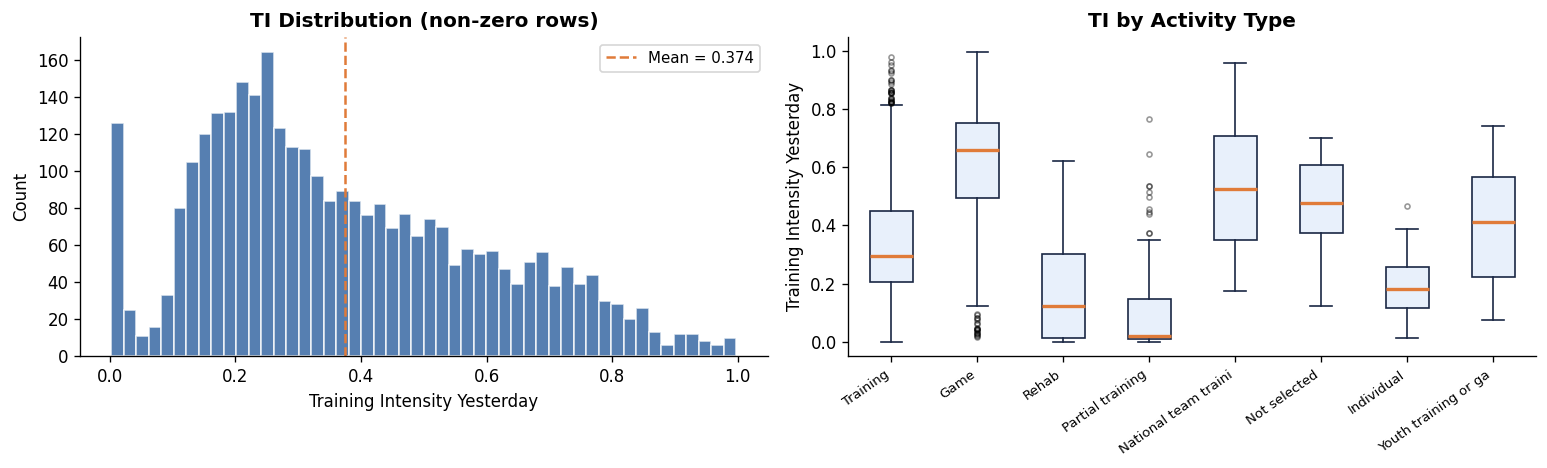

In [19]:
# ── 4.4  TI distribution visualisation ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# overall distribution (excluding zeros = rest days)
ti_nonzero = ti.dropna().loc[ti > 0]
axes[0].hist(ti_nonzero, bins=50, color=C_BLUE, edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Training Intensity Yesterday')
axes[0].set_ylabel('Count')
axes[0].set_title('TI Distribution (non-zero rows)', fontweight='bold')
axes[0].axvline(ti_nonzero.mean(), color=C_AMBER, linestyle='--',
                label=f'Mean = {ti_nonzero.mean():.3f}')
axes[0].legend(fontsize=9)

# TI by activity type (top categories)
top_acts = df['Activity Type Yesterday'].value_counts().head(8).index
ti_by_act = [
    df.loc[df['Activity Type Yesterday'] == act, 'Training Intensity Yesterday'].dropna()
    for act in top_acts
]
axes[1].boxplot(ti_by_act, labels=[str(a)[:20] for a in top_acts],
                patch_artist=True,
                boxprops=dict(facecolor=C_LTBLUE, color=C_NAVY),
                medianprops=dict(color=C_AMBER, linewidth=2),
                whiskerprops=dict(color=C_NAVY),
                capprops=dict(color=C_NAVY),
                flierprops=dict(marker='o', markersize=3, color=C_GRAY, alpha=0.4))
axes[1].set_xticklabels([str(a)[:20] for a in top_acts], rotation=35, ha='right', fontsize=8)
axes[1].set_ylabel('Training Intensity Yesterday')
axes[1].set_title('TI by Activity Type', fontweight='bold')

fig.tight_layout()
plt.show()

## 5. Temporal Variable Consistency

**Rules:**
- `Days Since Game >= 1` always (on match day the game hasn't happened yet).
- `Days Until Match == 0` only on `Match Day == 1` rows; and all `Match Day == 1` rows must have `Days Until Match == 0`.
- `Days Until Match >= 0` always.
- Both variables should monotonically progress within a match cycle (DSG increases, DUM decreases toward 0).

In [20]:
# ── 5.1  Days Since Game == 0 (must never happen) ────────────────────────────
dsg_zero = df[df['Days Since Game'] == 0]
dsg_neg  = df[df['Days Since Game'] < 0]
print(f"Days Since Game == 0 : {len(dsg_zero):,} (must be 0)")
print(f"Days Since Game <  0 : {len(dsg_neg):,}  (must be 0)")
if not dsg_zero.empty:
    print(dsg_zero[['Date','Player ID','Days Since Game','Activity Type Today']].head(10).to_string())
log('Days Since Game never == 0',
    'PASS' if dsg_zero.empty else 'FAIL', len(dsg_zero))
log('Days Since Game never < 0',
    'PASS' if dsg_neg.empty else 'FAIL', len(dsg_neg))

Days Since Game == 0 : 0 (must be 0)
Days Since Game <  0 : 0  (must be 0)
✅  Days Since Game never == 0
✅  Days Since Game never < 0


In [21]:
# ── 5.2  Days Until Match consistency ────────────────────────────────────────
dum_neg       = df[df['Days Until Match'] < 0]
# DUM==0 on non-match days
dum_zero_nonmatch = df[(df['Days Until Match'] == 0) & (df['Match Day'] != 1)]
# DUM!=0 on match days
dum_nonzero_match = df[(df['Days Until Match'] != 0) & (df['Match Day'] == 1)]

print(f"Days Until Match < 0                          : {len(dum_neg):,}")
print(f"Days Until Match == 0 but Match Day != 1      : {len(dum_zero_nonmatch):,}")
print(f"Days Until Match != 0 but Match Day == 1      : {len(dum_nonzero_match):,}")

if not dum_nonzero_match.empty:
    print("\nMatch days where DUM != 0:")
    print(dum_nonzero_match[['Date','Player ID','Days Until Match','Match Day','Selected']].head(10).to_string())

n_issues = len(dum_neg) + len(dum_zero_nonmatch) + len(dum_nonzero_match)
log('Days Until Match logic (0 iff match day)',
    'PASS' if n_issues == 0 else 'FAIL', n_issues)

Days Until Match < 0                          : 0
Days Until Match == 0 but Match Day != 1      : 0
Days Until Match != 0 but Match Day == 1      : 240

Match days where DUM != 0:
         Date  Player ID  Days Until Match  Match Day  Selected
0  2025-07-27          7              48.0          1       NaN
7  2025-07-27         23              35.0          1       0.0
8  2025-07-27          4              55.0          1       NaN
13 2025-07-27          5              35.0          1       NaN
16 2025-07-27         13              39.0          1       0.0
17 2025-07-27         12              28.0          1       NaN
18 2025-07-27         21             109.0          1       NaN
20 2025-07-27         24               NaN          1       0.0
24 2025-07-27         19              14.0          1       0.0
26 2025-07-27         26              14.0          1       0.0
❌  Days Until Match logic (0 iff match day) — 240 affected rows


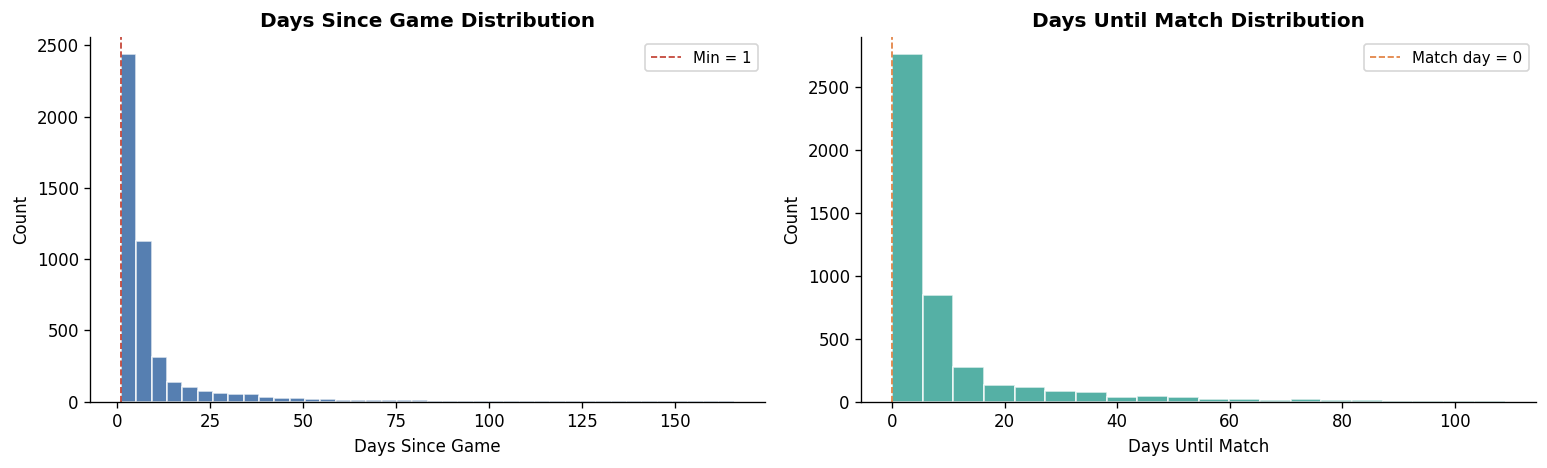

In [22]:
# ── 5.3  Temporal distribution of DSG and DUM ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['Days Since Game'].dropna(), bins=40,
             color=C_BLUE, edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Days Since Game')
axes[0].set_ylabel('Count')
axes[0].set_title('Days Since Game Distribution', fontweight='bold')
axes[0].axvline(1, color=C_RED, linestyle='--', linewidth=1, label='Min = 1')
axes[0].legend(fontsize=9)

axes[1].hist(df['Days Until Match'].dropna(), bins=20,
             color=C_TEAL, edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Days Until Match')
axes[1].set_ylabel('Count')
axes[1].set_title('Days Until Match Distribution', fontweight='bold')
axes[1].axvline(0, color=C_AMBER, linestyle='--', linewidth=1, label='Match day = 0')
axes[1].legend(fontsize=9)

fig.tight_layout()
plt.show()

In [23]:
# ── 5.4  Within-player monotonicity check (DSG should increase, DUM should decrease) ──
# Within a cycle (between two consecutive match days per player), DSG must be non-decreasing
# and DUM must be non-increasing as we move through time.

dsg_violations = 0
dum_violations = 0

for pid, grp in df.sort_values('Date').groupby('Player ID'):
    grp = grp.reset_index(drop=True)
    # identify cycle boundaries (rows where Activity Type Today == 'Game')
    game_idx = grp.index[grp['Activity Type Today'] == 'Game'].tolist()
    boundaries = [-1] + game_idx

    for i in range(len(boundaries)):
        start = boundaries[i] + 1
        end   = boundaries[i+1] + 1 if i+1 < len(boundaries) else len(grp)
        cycle = grp.iloc[start:end]

        if len(cycle) < 2:
            continue

        dsg = cycle['Days Since Game'].dropna()
        dum = cycle['Days Until Match'].dropna()

        # DSG should be non-decreasing
        if len(dsg) > 1 and (dsg.diff().dropna() < 0).any():
            dsg_violations += 1

        # DUM should be non-increasing
        if len(dum) > 1 and (dum.diff().dropna() > 0).any():
            dum_violations += 1

print(f"Cycles where Days Since Game is not non-decreasing : {dsg_violations}")
print(f"Cycles where Days Until Match is not non-increasing : {dum_violations}")

log('Days Since Game non-decreasing within cycles',
    'PASS' if dsg_violations == 0 else 'WARN', dsg_violations)
log('Days Until Match non-increasing within cycles',
    'PASS' if dum_violations == 0 else 'WARN', dum_violations)

Cycles where Days Since Game is not non-decreasing : 0
Cycles where Days Until Match is not non-increasing : 0
✅  Days Since Game non-decreasing within cycles
✅  Days Until Match non-increasing within cycles


## 6. ACWR Flag Consistency

**Rule:** `Any ACWR Danger == 1` if and only if **any** of the four ACWR columns exceeds 1.5.

This was flagged during preliminary investigation as having ~2,964 mismatches. We now investigate the nature of these discrepancies.

In [24]:
# ── 6.1  Recompute flag and compare ───────────────────────────────────────────
acwr_vals = df[ACWR_COLS]

# Recomputed flag
flag_computed = (acwr_vals > 1.5).any(axis=1).astype(int)

# Stored flag (may have NaN)
flag_stored = df['Any ACWR Danger'].fillna(0).astype(int)

mismatch = df[flag_computed != flag_stored].copy()
mismatch['flag_stored']   = flag_stored[mismatch.index]
mismatch['flag_computed'] = flag_computed[mismatch.index]

print(f"Total rows           : {len(df):,}")
print(f"Stored flag == 1     : {(flag_stored == 1).sum():,}")
print(f"Computed flag == 1   : {(flag_computed == 1).sum():,}")
print(f"Mismatches           : {len(mismatch):,}")
print()
print("Mismatch breakdown:")
mismatch_types = mismatch.groupby(['flag_stored','flag_computed']).size().rename('count')
print(mismatch_types)

Total rows           : 5,234
Stored flag == 1     : 725
Computed flag == 1   : 725
Mismatches           : 0

Mismatch breakdown:
Series([], Name: count, dtype: int64)


In [25]:
# ── 6.2  Diagnose: where is stored=1 but computed=0? ─────────────────────────
# Stored says danger but we compute no ACWR > 1.5
stored_1_comp_0 = mismatch[(mismatch['flag_stored'] == 1) & (mismatch['flag_computed'] == 0)]
# Stored says no danger but ACWR > 1.5 exists
stored_0_comp_1 = mismatch[(mismatch['flag_stored'] == 0) & (mismatch['flag_computed'] == 1)]

print(f"Stored=1 but computed=0 : {len(stored_1_comp_0):,}  (flag looks too aggressive)")
print(f"Stored=0 but computed=1 : {len(stored_0_comp_1):,}  (flag is missing positives)")
print()

# Examine max ACWR in stored=1 / computed=0 cases
if not stored_1_comp_0.empty:
    max_acwr = acwr_vals.loc[stored_1_comp_0.index].max(axis=1)
    print(f"Max ACWR in stored=1/computed=0 rows: {max_acwr.describe().round(4).to_string()}")
    # Check if they're just very close to 1.5
    near_threshold = (max_acwr > 1.4) & (max_acwr <= 1.5)
    print(f"Of which max ACWR in (1.4, 1.5]: {near_threshold.sum()}")
    print(f"Of which max ACWR <= 1.4       : {(max_acwr <= 1.4).sum()}")

print()
# Examine max ACWR in stored=0 / computed=1 cases
if not stored_0_comp_1.empty:
    max_acwr2 = acwr_vals.loc[stored_0_comp_1.index].max(axis=1)
    print(f"Max ACWR in stored=0/computed=1 rows: {max_acwr2.describe().round(4).to_string()}")

Stored=1 but computed=0 : 0  (flag looks too aggressive)
Stored=0 but computed=1 : 0  (flag is missing positives)




In [26]:
# ── 6.3  Investigate NaN ACWR rows ───────────────────────────────────────────
# NaN in any ACWR col → our computed flag uses .any() which ignores NaN by default
acwr_any_nan = acwr_vals.isna().any(axis=1)
acwr_all_nan = acwr_vals.isna().all(axis=1)

print(f"Rows with at least one NaN ACWR : {acwr_any_nan.sum():,}")
print(f"Rows with all NaN ACWR          : {acwr_all_nan.sum():,}")
print()

# Are mismatches concentrated in NaN rows?
mismatch_nan = mismatch[acwr_any_nan[mismatch.index]]
print(f"Mismatches where at least one ACWR is NaN : {len(mismatch_nan):,}")
print(f"Mismatches where no ACWR is NaN           : {len(mismatch) - len(mismatch_nan):,}")
print()

# Show sample from stored=1/computed=0 with no NaN ACWR
pure_mismatch = stored_1_comp_0[~acwr_any_nan[stored_1_comp_0.index]]
print(f"Stored=1 / computed=0 with NO NaN ACWR: {len(pure_mismatch):,}")
if not pure_mismatch.empty:
    print(pure_mismatch[['Date','Player ID'] + ACWR_COLS + ['flag_stored','flag_computed']].head(10).to_string())

Rows with at least one NaN ACWR : 227
Rows with all NaN ACWR          : 156

Mismatches where at least one ACWR is NaN : 0
Mismatches where no ACWR is NaN           : 0

Stored=1 / computed=0 with NO NaN ACWR: 0


In [27]:
# ── 6.4  Summary and recommendation ───────────────────────────────────────────
# Determine if discrepancy is systematic (preprocessing threshold differs?)
# Check if original flag used >= 1.5 vs > 1.5
flag_geq = (acwr_vals >= 1.5).any(axis=1).astype(int)
mismatch_geq = (flag_geq != flag_stored).sum()

print(f"Mismatches with threshold > 1.5  : {len(mismatch):,}")
print(f"Mismatches with threshold >= 1.5 : {mismatch_geq:,}")
print()

# Correct representation of the issue
n_total_mismatch = len(mismatch)
pct = n_total_mismatch / len(df) * 100

if n_total_mismatch == 0:
    status = 'PASS'
elif pct < 5:
    status = 'WARN'
else:
    status = 'FAIL'

log('Any ACWR Danger flag consistent with ACWR > 1.5',
    status, n_total_mismatch,
    note=f'{pct:.1f}% of rows; stored=1/comp=0: {len(stored_1_comp_0)}, stored=0/comp=1: {len(stored_0_comp_1)}')

print("\nNote: If stored flag used a different threshold or NaN-handling rule,")
print("consider rerunning preprocessing to recompute Any ACWR Danger consistently.")

Mismatches with threshold > 1.5  : 0
Mismatches with threshold >= 1.5 : 25

✅  Any ACWR Danger flag consistent with ACWR > 1.5  [0.0% of rows; stored=1/comp=0: 0, stored=0/comp=1: 0]

Note: If stored flag used a different threshold or NaN-handling rule,
consider rerunning preprocessing to recompute Any ACWR Danger consistently.


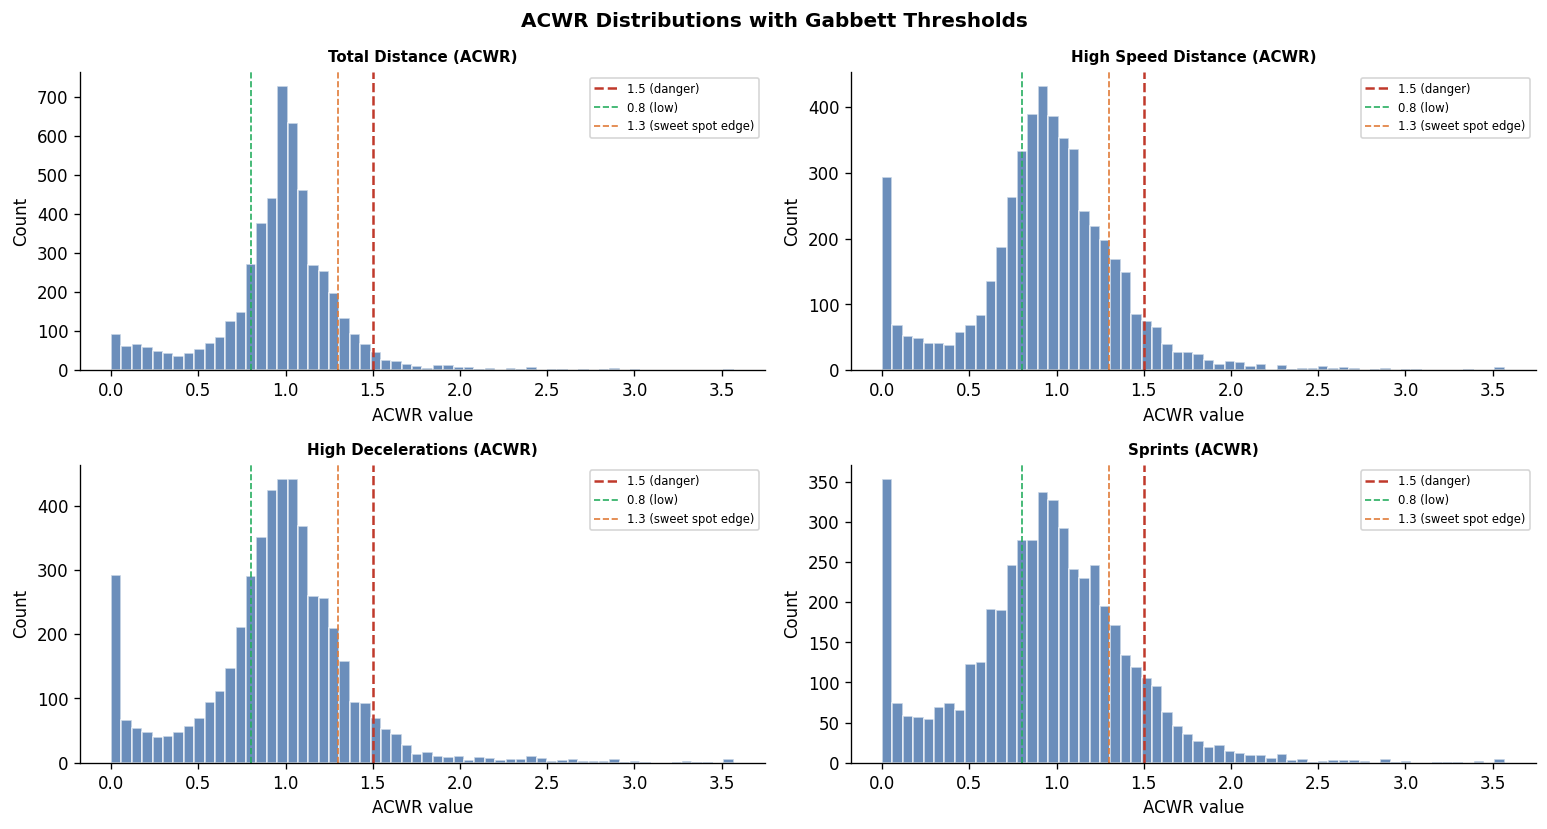

In [28]:
# ── 6.5  ACWR distribution per column ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

for ax, col in zip(axes.flatten(), ACWR_COLS):
    vals = df[col].dropna()
    ax.hist(vals, bins=60, color=C_BLUE, edgecolor='white', alpha=0.7)
    ax.axvline(1.5, color=C_RED,   linestyle='--', linewidth=1.5, label='1.5 (danger)')
    ax.axvline(0.8, color=C_GREEN, linestyle='--', linewidth=1,   label='0.8 (low)')
    ax.axvline(1.3, color=C_AMBER, linestyle='--', linewidth=1,   label='1.3 (sweet spot edge)')
    ax.set_title(col.replace(' Yesterday',''), fontweight='bold', fontsize=9)
    ax.set_xlabel('ACWR value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

fig.suptitle('ACWR Distributions with Gabbett Thresholds', fontweight='bold')
fig.tight_layout()
plt.show()

## 7. Status & Status Decrease Logic

**Rules:**
- `Status` ∈ {Available, Attention, Injured, Sick, Absent} — no unexpected values.
- `Status Decrease == 1` iff the player's status worsened from the **previous row** (within same player): Available→Attention, Available→Injured, or Attention→Injured.
- `Status Decrease == 0` otherwise (stable, improvement, NaN predecessor).
- No row with `Status Decrease == 1` should represent an improvement.

In [29]:
# ── 7.1  Valid Status values ───────────────────────────────────────────────────
VALID_STATUSES = {'Available', 'Attention', 'Injured', 'Sick', 'Absent'}
status_counts = df['Status'].value_counts(dropna=False)
print("Status distribution:")
print(status_counts)
print()

invalid_status = df[~df['Status'].isin(VALID_STATUSES)]
print(f"Rows with unexpected Status values : {len(invalid_status):,}")
if not invalid_status.empty:
    print(invalid_status[['Date','Player ID','Status']].head(10).to_string())

log('Status values are valid',
    'PASS' if invalid_status.empty else 'FAIL', len(invalid_status))

Status distribution:
Status
Available    3681
Injured       822
Attention     697
Sick           20
Absent         14
Name: count, dtype: int64

Rows with unexpected Status values : 0
✅  Status values are valid


In [30]:
# ── 7.2  Recompute Status Decrease and validate ───────────────────────────────
# Severity order: Available=0, Attention=1, Injured=2, Sick/Absent=NaN (excluded from DTR)
severity = {'Available': 0, 'Attention': 1, 'Injured': 2}

df_sorted = df.sort_values(['Player ID', 'Date']).copy()
df_sorted['_severity']      = df_sorted['Status'].map(severity)
df_sorted['_prev_severity'] = df_sorted.groupby('Player ID')['_severity'].shift(1)

# A status decrease is when severity increases
df_sorted['_sd_computed'] = (
    (df_sorted['_severity'] > df_sorted['_prev_severity'])
    & df_sorted['_severity'].notna()
    & df_sorted['_prev_severity'].notna()
).astype(int)

# Compare with stored
sd_stored   = df_sorted['Status Decrease'].fillna(0).astype(int)
sd_computed = df_sorted['_sd_computed']

sd_mismatch = df_sorted[sd_stored != sd_computed]

print(f"Stored   Status Decrease == 1 : {(sd_stored == 1).sum():,}")
print(f"Computed Status Decrease == 1 : {(sd_computed == 1).sum():,}")
print(f"Mismatches                    : {len(sd_mismatch):,}")

if not sd_mismatch.empty:
    sd_mismatch['sd_stored']   = sd_stored[sd_mismatch.index]
    sd_mismatch['sd_computed'] = sd_computed[sd_mismatch.index]
    print("\nSample mismatches:")
    print(sd_mismatch[['Date','Player ID','Status','_prev_severity','_severity','sd_stored','sd_computed']]
          .head(15).to_string())

log('Status Decrease flag matches computed transitions',
    'PASS' if sd_mismatch.empty else 'WARN', len(sd_mismatch))

Stored   Status Decrease == 1 : 134
Computed Status Decrease == 1 : 134
Mismatches                    : 0
✅  Status Decrease flag matches computed transitions


Status Decrease events : 134  (2.56% of rows)

Status decrease breakdown (from → to):
From       To       
Attention  Injured      12
Available  Attention    90
           Injured      32
dtype: int64


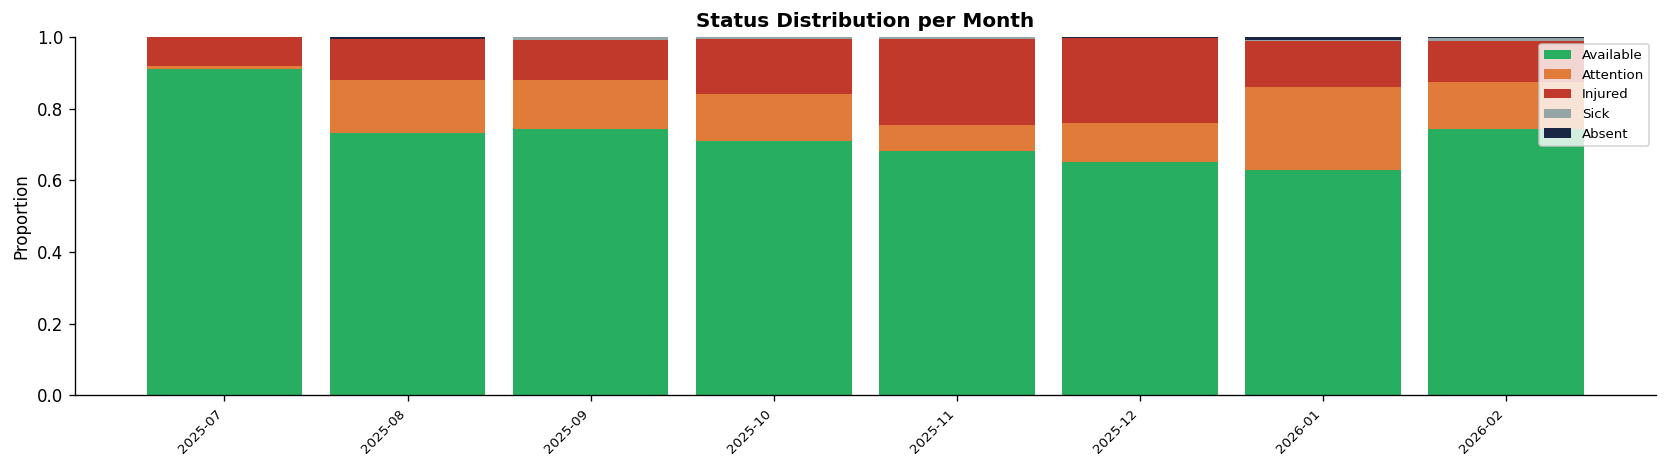

In [31]:
# ── 7.3  Status Decrease count and distribution ───────────────────────────────
sd_count = (df['Status Decrease'] == 1).sum()
sd_rate  = sd_count / len(df) * 100

print(f"Status Decrease events : {sd_count:,}  ({sd_rate:.2f}% of rows)")
print()

# breakdown by transition type
df_sorted['_prev_status'] = df_sorted.groupby('Player ID')['Status'].shift(1)
decrease_rows = df_sorted[df_sorted['_sd_computed'] == 1]
transition_counts = decrease_rows.groupby(['_prev_status','Status']).size()
transition_counts.index.names = ['From', 'To']
print("Status decrease breakdown (from → to):")
print(transition_counts)

# Visualise status distribution over time
fig, ax = plt.subplots(figsize=(14, 4))
status_order = ['Available', 'Attention', 'Injured', 'Sick', 'Absent']
colors_status = [C_GREEN, C_AMBER, C_RED, C_GRAY, C_NAVY]

# Monthly proportions
df_sorted['_month'] = df_sorted['Date'].dt.to_period('M')
monthly_status = df_sorted.groupby(['_month','Status']).size().unstack(fill_value=0)
monthly_status = monthly_status.reindex(columns=status_order, fill_value=0)
monthly_status_pct = monthly_status.div(monthly_status.sum(axis=1), axis=0)

bottom = pd.Series(0, index=range(len(monthly_status_pct)))
x = range(len(monthly_status_pct))
for col, color in zip(status_order, colors_status):
    if col in monthly_status_pct.columns:
        ax.bar(x, monthly_status_pct[col].values, bottom=bottom.values,
               color=color, label=col, width=0.85)
        bottom += monthly_status_pct[col].values

ax.set_xticks(range(len(monthly_status_pct)))
ax.set_xticklabels([str(m) for m in monthly_status_pct.index], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Proportion')
ax.set_title('Status Distribution per Month', fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
fig.tight_layout()
plt.show()

## 8. Wellness Z-Score Validation

**Rules:**
- Z-scores are **per-player** 28-day rolling z-scores → each player's mean should be near 0 and std near 1.
- No player should have all z-scores identical (indicates no variance in input → failed computation).
- Extreme outliers (|z| > 5) may indicate data entry errors.
- Composite scores (Physical State, Mental State, Overall Wellbeing) must be consistent averages of their sub-components.

In [32]:
# ── 8.1  Per-player z-score statistics ───────────────────────────────────────
print("Global z-score statistics (should be near 0 mean, ~1 std if well-distributed):")
print(df[WELLNESS_Z_COLS].describe().round(3))
print()

# Per-player mean and std of each z-score
player_z_stats = df.groupby('Player ID')[WELLNESS_Z_COLS].agg(['mean','std']).round(3)
print("Per-player z-score means (should be near 0):")
means = player_z_stats.loc[:, (slice(None), 'mean')]
means.columns = [c[0] for c in means.columns]
print(means.to_string())

Global z-score statistics (should be near 0 mean, ~1 std if well-distributed):
       Fatigue (z)  Readiness (z)  Soreness (z)  Sleep Quality (z)  \
count     2711.000       2711.000      2711.000           2711.000   
mean         0.044          0.014         0.060             -0.018   
std          1.045          1.091         1.007              0.979   
min         -9.000         -6.500        -5.400             -4.500   
25%         -0.400         -0.300        -0.400             -0.500   
50%          0.100          0.300         0.000              0.200   
75%          0.700          0.500         0.700              0.600   
max          5.100          4.500         6.200              3.300   

       Stress (z)  Mood (z)  
count    2711.000  2711.000  
mean        0.035    -0.036  
std         1.071     1.028  
min        -8.900    -6.300  
25%        -0.500    -0.500  
50%         0.200     0.300  
75%         0.800     0.600  
max         4.800     5.900  

Per-player z-score 

In [33]:
# ── 8.2  Extreme outliers (|z| > 5) ─────────────────────────────────────────
extreme_z = df[WELLNESS_Z_COLS].abs() > 5
n_extreme = extreme_z.sum()

print("Extreme z-score values (|z| > 5):")
print(n_extreme[n_extreme > 0])
print()

# show affected rows
extreme_mask = extreme_z.any(axis=1)
if extreme_mask.any():
    print(f"Rows with at least one |z| > 5: {extreme_mask.sum():,}")
    print(df.loc[extreme_mask, ['Date','Player ID'] + WELLNESS_Z_COLS].to_string())
else:
    print("No extreme z-score outliers found.")

log('No extreme z-score outliers (|z| > 5)',
    'PASS' if not extreme_mask.any() else 'WARN',
    extreme_mask.sum())

Extreme z-score values (|z| > 5):
Fatigue (z)       3
Readiness (z)     6
Soreness (z)      3
Stress (z)       10
Mood (z)          4
dtype: int64

Rows with at least one |z| > 5: 25
           Date  Player ID  Fatigue (z)  Readiness (z)  Soreness (z)  Sleep Quality (z)  Stress (z)  Mood (z)
47   2025-07-28          1         -0.8           -4.0          -0.2               -0.9        -5.3      -4.0
52   2025-07-28         10          0.5            1.0           0.6                0.3         1.0      -5.2
134  2025-07-31         26          0.2            0.0           2.0                1.1        -5.1       0.3
216  2025-08-04          3          1.0            1.0          -5.3               -2.9         1.0      -5.3
242  2025-08-04          1         -2.2           -3.1          -2.5               -0.8        -5.2      -3.3
319  2025-08-07         14         -0.3           -6.0          -0.2                0.4        -1.3       0.3
677  2025-08-21          3          1.0        

In [34]:
# ── 8.3  Composite score consistency ─────────────────────────────────────────
# Physical State = mean(Fatigue(z), Readiness(z), Soreness(z))
# Mental State   = mean(Sleep Quality(z), Stress(z), Mood(z))
# Overall Wellbeing = mean(all 6 z-scores)

PHYS_COLS = ['Fatigue (z)', 'Readiness (z)', 'Soreness (z)']
MENT_COLS = ['Sleep Quality (z)', 'Stress (z)', 'Mood (z)']
ALL_W     = PHYS_COLS + MENT_COLS

TOLERANCE_COMPOSITE = 0.01  # small floating point tolerance

phys_computed = df[PHYS_COLS].mean(axis=1)
ment_computed = df[MENT_COLS].mean(axis=1)
well_computed = df[ALL_W].mean(axis=1)

def composite_mismatch(stored, computed, name, tol=TOLERANCE_COMPOSITE):
    both_valid = stored.notna() & computed.notna()
    diff = (stored - computed).abs()
    bad  = df[both_valid & (diff > tol)]
    print(f"{name}: {len(bad):,} mismatches out of {both_valid.sum():,} valid rows")
    if not bad.empty:
        print(bad[['Date','Player ID']].assign(
            stored=stored[bad.index].round(4),
            computed=computed[bad.index].round(4),
            diff=diff[bad.index].round(6)
        ).head(10).to_string())
    return len(bad)

n1 = composite_mismatch(df['Physical State'],    phys_computed, 'Physical State')
n2 = composite_mismatch(df['Mental State'],      ment_computed, 'Mental State')
n3 = composite_mismatch(df['Overall Wellbeing'], well_computed, 'Overall Wellbeing')

log('Composite wellness scores consistent with sub-components',
    'PASS' if (n1 + n2 + n3) == 0 else 'WARN', n1 + n2 + n3)

Physical State: 0 mismatches out of 2,711 valid rows
Mental State: 0 mismatches out of 2,711 valid rows
Overall Wellbeing: 0 mismatches out of 2,711 valid rows
✅  Composite wellness scores consistent with sub-components


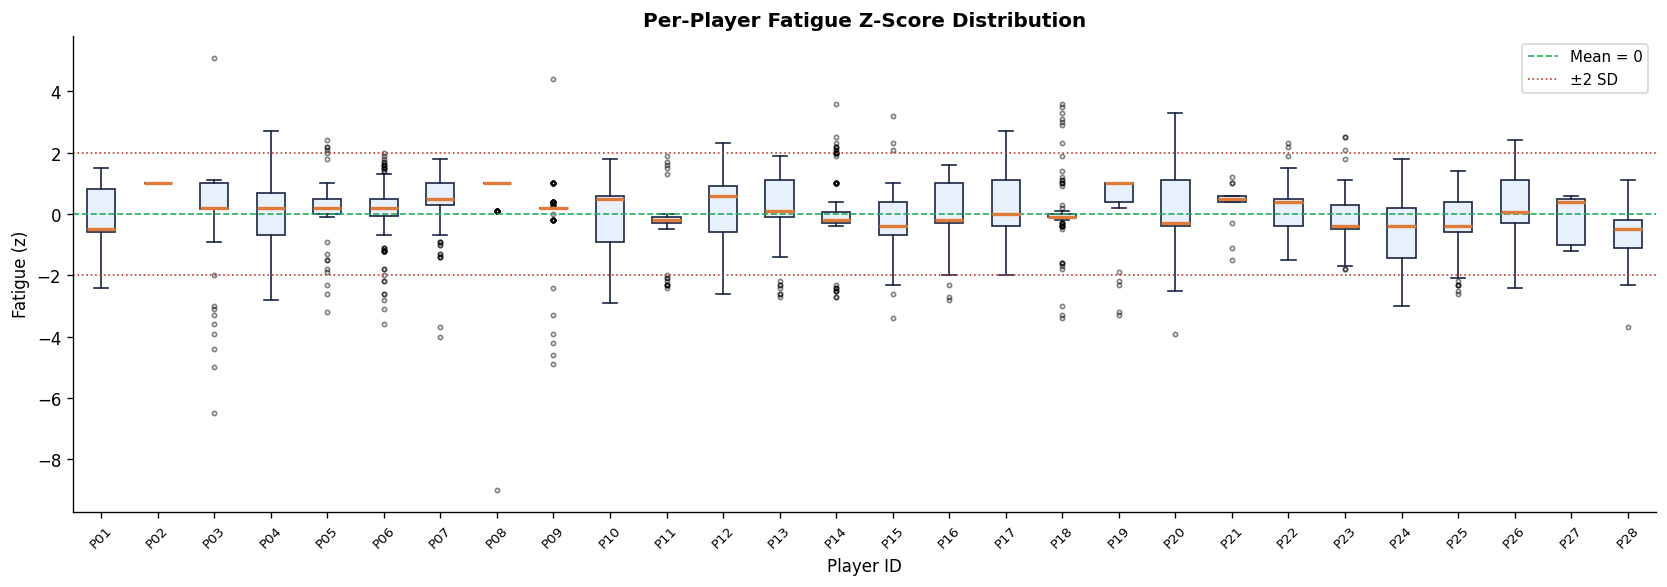

In [35]:
# ── 8.4  Visualise z-score distributions per player ─────────────────────────
# Box plot: Fatigue(z) per player ID
fig, ax = plt.subplots(figsize=(14, 5))

player_fatigue = [df.loc[df['Player ID'] == pid, 'Fatigue (z)'].dropna()
                  for pid in ALL_PLAYER_IDS]
bp = ax.boxplot(player_fatigue,
                labels=[f'P{pid:02d}' for pid in ALL_PLAYER_IDS],
                patch_artist=True,
                boxprops=dict(facecolor=C_LTBLUE, color=C_NAVY),
                medianprops=dict(color=C_AMBER, linewidth=2),
                whiskerprops=dict(color=C_NAVY),
                capprops=dict(color=C_NAVY),
                flierprops=dict(marker='o', markersize=2.5, color=C_GRAY, alpha=0.5))

ax.axhline(0,  color=C_GREEN, linestyle='--', linewidth=1, label='Mean = 0')
ax.axhline(2,  color=C_RED,   linestyle=':', linewidth=1,  label='±2 SD')
ax.axhline(-2, color=C_RED,   linestyle=':', linewidth=1)
ax.set_xlabel('Player ID')
ax.set_ylabel('Fatigue (z)')
ax.set_title('Per-Player Fatigue Z-Score Distribution', fontweight='bold')
ax.tick_params(axis='x', labelrotation=45, labelsize=8)
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

## 9. Cross-Dataset Merge Coverage

**Rules:**
- Raw GPS/HR columns (from Raw_Data merge): should be filled for training/game rows, NaN for free/rest days.
- Match performance columns (from Games merge): should be filled exactly the day **after** a game the player played — i.e., rows where Activity Type Yesterday == 'Game'.
- Check fill rates and identify unexpected NaN or unexpected non-NaN.

In [36]:
# ── 9.1  Raw GPS/HR column fill rates ────────────────────────────────────────
RAW_GPS_COLS = [
    'Total Minutes Yesterday',
    'Total Distance (m) Yesterday',
    'High Speed Distance (m) Yesterday',
    'Avg Heart Rate Yesterday',
    'Heart Rate Exertion Yesterday',
]

MATCH_PERF_COLS = [
    'Match HID Per BIP Yesterday',
    'Match HIE Per BIP Yesterday',
    'Match Minutes Played Yesterday',
]

print("Raw GPS/HR columns — overall fill rates:")
for col in RAW_GPS_COLS:
    n_filled = df[col].notna().sum()
    pct = n_filled / len(df) * 100
    print(f"  {col:<45} : {n_filled:,} filled ({pct:.1f}%)")

print()
print("Match performance columns — overall fill rates:")
for col in MATCH_PERF_COLS:
    n_filled = df[col].notna().sum()
    pct = n_filled / len(df) * 100
    print(f"  {col:<45} : {n_filled:,} filled ({pct:.1f}%)")

Raw GPS/HR columns — overall fill rates:
  Total Minutes Yesterday                       : 2,517 filled (48.1%)
  Total Distance (m) Yesterday                  : 2,517 filled (48.1%)
  High Speed Distance (m) Yesterday             : 2,517 filled (48.1%)
  Avg Heart Rate Yesterday                      : 2,517 filled (48.1%)
  Heart Rate Exertion Yesterday                 : 2,517 filled (48.1%)

Match performance columns — overall fill rates:
  Match HID Per BIP Yesterday        : 362 filled (6.9%)
  Match HIE Per BIP Yesterday           : 362 filled (6.9%)
  Match Minutes Played Yesterday                : 362 filled (6.9%)


In [37]:
# ── 9.2  Match performance: should be filled only day after a game ────────────
# Rows where Activity Type Yesterday == 'Game' should have match performance data
day_after_game = df[df['Activity Type Yesterday'] == 'Game']
print(f"Rows where Activity Type Yesterday == 'Game' : {len(day_after_game):,}")

for col in MATCH_PERF_COLS:
    filled = day_after_game[col].notna().sum()
    pct = filled / len(day_after_game) * 100 if len(day_after_game) > 0 else 0
    print(f"  {col:<45}: {filled:,}/{len(day_after_game):,} ({pct:.1f}%) filled")

print()
# Match performance filled on NON game-day-after rows (unexpected?)
day_not_after_game = df[df['Activity Type Yesterday'] != 'Game']
print(f"Rows where Activity Type Yesterday != 'Game' : {len(day_not_after_game):,}")
for col in MATCH_PERF_COLS:
    unexpected = day_not_after_game[col].notna().sum()
    if unexpected > 0:
        print(f"  ⚠️  {col}: {unexpected:,} unexpectedly filled")

# Fill rate check on day-after-game rows
perf_fill_rate = day_after_game[MATCH_PERF_COLS[0]].notna().sum() / len(day_after_game) * 100 if len(day_after_game) > 0 else 0
log('Match performance coverage (day after game)',
    'PASS' if perf_fill_rate >= 50 else 'WARN',
    len(day_after_game) - day_after_game[MATCH_PERF_COLS[0]].notna().sum(),
    note=f'{perf_fill_rate:.1f}% fill rate on day-after-game rows')

Rows where Activity Type Yesterday == 'Game' : 499
  Match HID Per BIP Yesterday       : 348/499 (69.7%) filled
  Match HIE Per BIP Yesterday          : 348/499 (69.7%) filled
  Match Minutes Played Yesterday               : 348/499 (69.7%) filled

Rows where Activity Type Yesterday != 'Game' : 4,735
  ⚠️  Match HID Per BIP Yesterday: 14 unexpectedly filled
  ⚠️  Match HIE Per BIP Yesterday: 14 unexpectedly filled
  ⚠️  Match Minutes Played Yesterday: 14 unexpectedly filled
✅  Match performance coverage (day after game) — 151 affected rows  [69.7% fill rate on day-after-game rows]


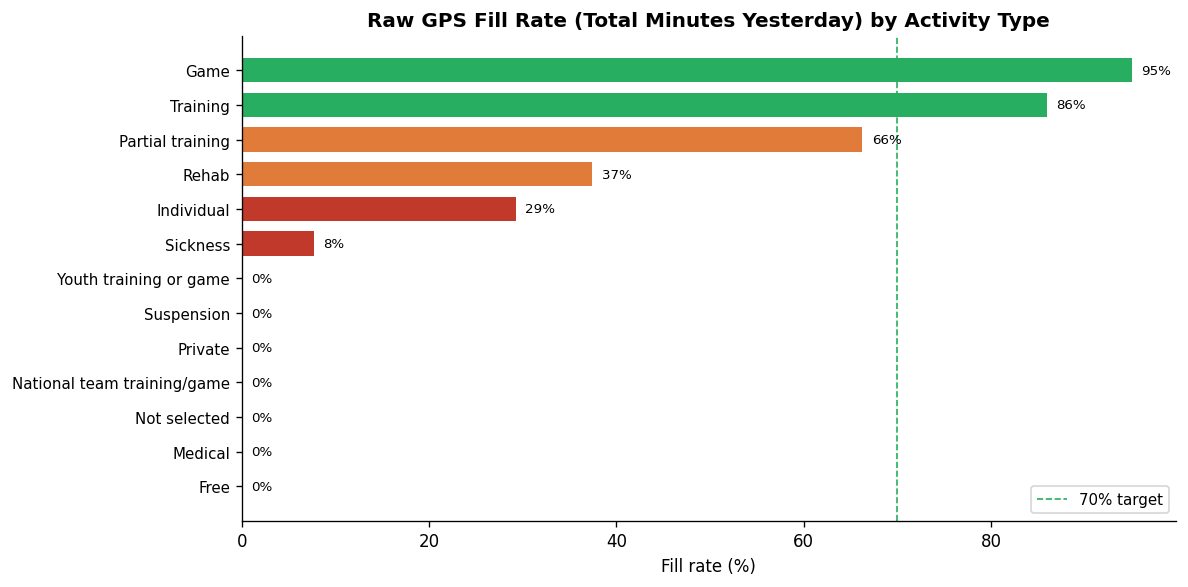

In [38]:
# ── 9.3  Raw GPS/HR: fill rate by activity type ───────────────────────────────
ref_col = 'Total Minutes Yesterday'
fill_by_act = (
    df.groupby('Activity Type Yesterday')[ref_col]
    .apply(lambda x: x.notna().mean() * 100)
    .sort_values(ascending=True)
    .rename('fill_%')
)

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = [C_GREEN if v >= 70 else (C_AMBER if v >= 30 else C_RED)
              for v in fill_by_act.values]
bars = ax.barh(range(len(fill_by_act)), fill_by_act.values, color=colors_bar, height=0.7)
ax.set_yticks(range(len(fill_by_act)))
ax.set_yticklabels([str(i)[:30] if i else '(NaN)' for i in fill_by_act.index], fontsize=9)
ax.set_xlabel('Fill rate (%)')
ax.set_title(f'Raw GPS Fill Rate ({ref_col}) by Activity Type', fontweight='bold')
ax.axvline(70, color=C_GREEN, linestyle='--', linewidth=1, label='70% target')
ax.legend(fontsize=9)

# annotate
for i, (bar, v) in enumerate(zip(bars, fill_by_act.values)):
    ax.text(min(v + 1, 98), bar.get_y() + bar.get_height()/2,
            f'{v:.0f}%', va='center', fontsize=8)

fig.tight_layout()
plt.show()

## 10. Free Day Consistency

**Rules:**
- Rows flagged as `Activity Type Yesterday == 'Free'` should have all GPS% == 0 **and** TI == 0.
- Rows where all GPS% are NaN (data-entry artefact, not a free day) should NOT be labelled 'Free'.
- Free days should NOT have Raw GPS/HR data filled (no session → no GPS data from Raw_Data).

In [39]:
# ── 10.1  NaN GPS% rows not labelled 'Free' (data artefacts) ─────────────────
gps_all_nan = df[GPS_PCT_COLS].isna().all(axis=1)
not_free     = df['Activity Type Yesterday'] != 'Free'
artefact_rows = df[gps_all_nan & not_free]

print(f"Rows with all GPS% == NaN and Activity != Free : {len(artefact_rows):,}")
if not artefact_rows.empty:
    print("Activity type distribution for these artefact rows:")
    print(artefact_rows['Activity Type Yesterday'].value_counts().head(10))

log('Rows with all-NaN GPS% not labelled as Free',
    'PASS' if artefact_rows.empty else 'WARN', len(artefact_rows))

Rows with all GPS% == NaN and Activity != Free : 1,997
Activity type distribution for these artefact rows:
Activity Type Yesterday
Rehab                          303
Partial training                54
Training                        41
National team training/game     37
Individual                      29
Not selected                    21
Youth training or game          15
Sickness                        12
Private                         10
Game                             4
Name: count, dtype: int64
⚠️   Rows with all-NaN GPS% not labelled as Free — 1,997 affected rows


In [40]:
# ── 10.2  Free days with Raw GPS/HR data filled (shouldn't have a session) ───
free_rows = df[df['Activity Type Yesterday'] == 'Free']
free_with_raw = free_rows[free_rows['Total Minutes Yesterday'].notna()]

print(f"Free day rows                          : {len(free_rows):,}")
print(f"Free days with Raw GPS/HR data filled  : {len(free_with_raw):,}")

if not free_with_raw.empty:
    print("\nSample free days with raw GPS data (unexpected):")
    print(free_with_raw[['Date','Player ID','Activity Type Yesterday',
                          'Total Minutes Yesterday','Training Intensity Yesterday']].head(10).to_string())

log('Free days have no Raw GPS/HR data',
    'PASS' if free_with_raw.empty else 'WARN', len(free_with_raw))

Free day rows                          : 1
Free days with Raw GPS/HR data filled  : 0
✅  Free days have no Raw GPS/HR data


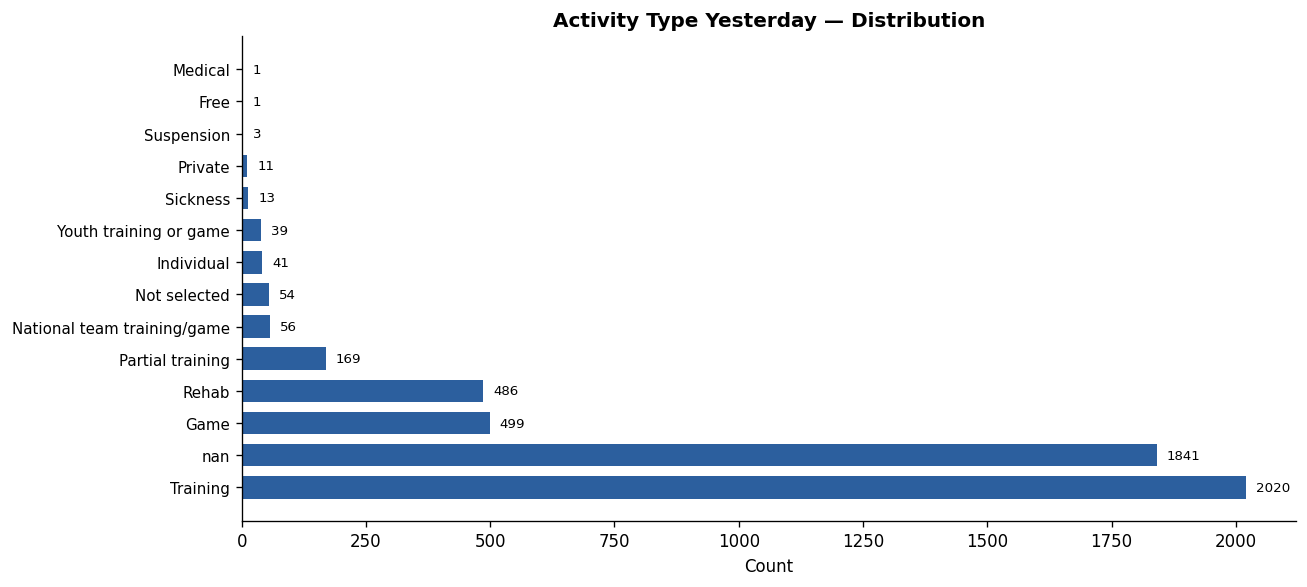

In [41]:
# ── 10.3  Activity type distribution overview ─────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

act_counts = df['Activity Type Yesterday'].value_counts(dropna=False)
act_counts.index = [str(i) if i is not None else '(NaN)' for i in act_counts.index]

colors_act = [C_RED if i == 'Free' else (C_BLUE if i != '(NaN)' else C_GRAY)
              for i in act_counts.index]
bars = ax.barh(range(len(act_counts)), act_counts.values, color=colors_act, height=0.7)
ax.set_yticks(range(len(act_counts)))
ax.set_yticklabels(act_counts.index, fontsize=9)
ax.set_xlabel('Count')
ax.set_title('Activity Type Yesterday — Distribution', fontweight='bold')

for bar, v in zip(bars, act_counts.values):
    ax.text(v + 20, bar.get_y() + bar.get_height()/2,
            str(v), va='center', fontsize=8)

fig.tight_layout()
plt.show()

## 11. Summary Dashboard

A concise pass/fail table for all quality checks performed in this notebook.

In [42]:
# ── 11.1  Summary table ───────────────────────────────────────────────────────
summary_rows = []
for name, result in CHECKS.items():
    icon = {'PASS': '✅', 'WARN': '⚠️ ', 'FAIL': '❌'}[result['status']]
    summary_rows.append({
        'Check'   : name,
        'Status'  : icon + ' ' + result['status'],
        'Affected': result['n'] if result['n'] > 0 else '',
        'Note'    : result['note'],
    })

summary_df = pd.DataFrame(summary_rows)

n_pass = sum(1 for r in CHECKS.values() if r['status'] == 'PASS')
n_warn = sum(1 for r in CHECKS.values() if r['status'] == 'WARN')
n_fail = sum(1 for r in CHECKS.values() if r['status'] == 'FAIL')

print(f"\n{'═'*70}")
print(f"  DATA QUALITY SUMMARY — RTT.xlsx")
print(f"{'═'*70}")
print(f"  ✅ PASS : {n_pass}")
print(f"  ⚠️  WARN : {n_warn}")
print(f"  ❌ FAIL : {n_fail}")
print(f"{'═'*70}\n")

pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 200)
print(summary_df.to_string(index=False))


══════════════════════════════════════════════════════════════════════
  DATA QUALITY SUMMARY — RTT.xlsx
══════════════════════════════════════════════════════════════════════
  ✅ PASS : 17
  ⚠️  WARN : 5
  ❌ FAIL : 1
══════════════════════════════════════════════════════════════════════

                                                      Check   Status Affected                                                 Note
               Missing player-date rows within active spans   ✅ PASS                                          0 player(s) affected
                                 Duplicate player-date rows   ✅ PASS                                                              
Match Day flag consistent across all players on match dates   ✅ PASS                                                              
          Selected players have Activity Type Today == Game   ✅ PASS                                                              
  Non-selected players on match days are NOT marked as

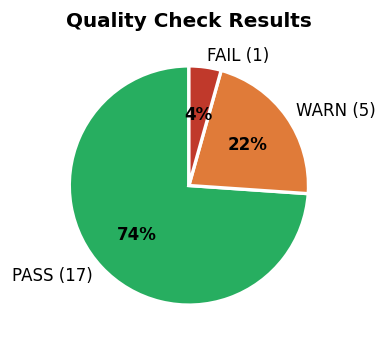


All checks complete.


In [43]:
# ── 11.2  Visual summary ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4, 3))

wedge_colors = [C_GREEN, C_AMBER, C_RED]
sizes = [n_pass, n_warn, n_fail]
labels = [f'PASS ({n_pass})', f'WARN ({n_warn})', f'FAIL ({n_fail})']
non_zero = [(s, l, c) for s, l, c in zip(sizes, labels, wedge_colors) if s > 0]

if non_zero:
    sizes_nz   = [x[0] for x in non_zero]
    labels_nz  = [x[1] for x in non_zero]
    colors_nz  = [x[2] for x in non_zero]
    wedges, texts, autotexts = ax.pie(
        sizes_nz, labels=labels_nz, colors=colors_nz,
        autopct='%1.0f%%', startangle=90,
        textprops={'fontsize': 10},
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    for at in autotexts:
        at.set_fontweight('bold')

ax.set_title('Quality Check Results', fontweight='bold', fontsize=12)
fig.tight_layout()
plt.show()

print("\nAll checks complete.")